### Heat diffusion with cooler

We further extend our example to include a cooler (increasing its cooling power over time), modeled by a hole in the middle of the domain with Neumann outflow condition on its boundary. We still assume a constant heat source in the remaining domain and therefore have

\begin{align*}
    \partial_t u -0.1\Delta u &= 1.0 &&\text{ in } (0, 2) \times \Omega \\
    u &= 0 , &&\text{ on } (0, 2) \times \partial ((0, 1) \times (0, 1)) \\
    0.1 \nabla u(t, x) \cdot n &= f(t) , &&\text{ on } (0,2) \times \partial H \\ 
    u(0, \cdot) &= 0 &&\text{ in } \Omega
\end{align*}

with $\Omega = (0, 1) \times (0, 1) \setminus H$, where $H=[0.5, 0.7]\times[0.4, 0.8]$.

In [ ]:
# This block is for GPU selection. Please execute.
import pathlib
import os
user = int(str(pathlib.Path().resolve())[22:24])
os.environ["CUDA_VISIBLE_DEVICES"]= str(user % 4)

In [2]:
import torch
import math

Next we implement the *Spaces* that appear in the problem:

In [ ]:
import torchphysics as tp
X = ...
U = ...
T = ...

Now we define our domain. The space domain is already completed, here you have to create the time interval and the Cartesian product of both.

In [ ]:
base = tp.domains.Parallelogram(X, [0,0], [1,0], [0,1])
hole = tp.domains.Parallelogram(X, [0.5, 0.4], [0.7, 0.4], [0.5, 0.8])
omega = ... # set substraction is performed by the minus (-) operator
time_interval = tp.domains.Interval(T, 0, 2.0)
product_domain = ... # TODO: Create the product domain of time and space.

Next we need to create some points, this is done by the *Sampler*. Here we need 3, one inside the domain, one for the boundary and one for the initial condition.

In [ ]:
# Add the product domain of time and space:
inner_sampler = tp.samplers.RandomUniformSampler(..., n_points=25000) 

outer_bound_sampler = tp.samplers.RandomUniformSampler(time_interval*base.boundary, n_points=10000)

# Add the missing hole boundary domain. Remember to create the product with the time domain.
hole_bound_sampler = tp.samplers.RandomUniformSampler(..., n_points=5000)

initial_sampler = tp.samplers.RandomUniformSampler(time_interval.boundary_left*omega, n_points=5000)

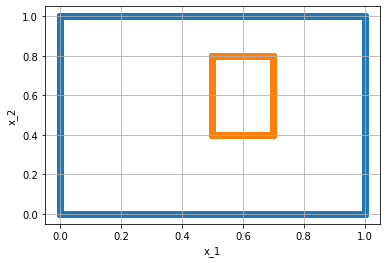

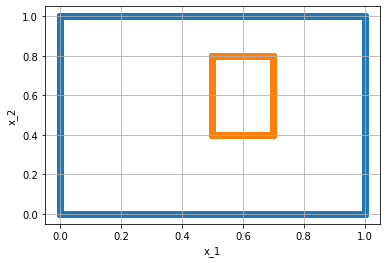

In [ ]:
# visualize the spatial domain via the sampling points, to check that it works as intended
tp.utils.scatter(X, outer_bound_sampler, hole_bound_sampler)

The neural network that learns the solution gets the time and space variable as an input and outputs the solution u. Add the correct spaces.

In [ ]:
model = tp.models.FCN(input_space=..., output_space=..., hidden=(30,30,30))

Now, we have to transform our mathematical conditions given by our PDE into corresponding training conditions.

First we handle the PDE itself.

In [ ]:
def pde_residual(u, x, t):
    return ...

pde_cond = tp.conditions.PINNCondition(model, inner_sampler, pde_residual)

In [ ]:
def boundary_residual(u):
    return u 

# pass the sampler for the outer boundary only
boundary_cond = tp.conditions.PINNCondition(model, ..., 
                                            ..., weight=50.0)

In [ ]:
# a cooler that increases the amount of cooling linearly in time
def f(t):
    return - 0.2 * t

def neumann_residual(u, x, t):
    return - 0.1 * tp.utils.normal_derivative(u, hole.boundary.normal(x), x) - f(t)

#fill in the gaps
neumann_cond = tp.conditions.PINNCondition(model, ...,
                                           ..., weight=100.0)

In [ ]:
# the initial condition is done already, since it is the same as before
def initial_residual(u):
    return u

initial_cond = tp.conditions.PINNCondition(model, initial_sampler, initial_residual) # add the model, sampler and residual

Before the training we collect all conditions and choose our training procedure:

In [ ]:
optim = tp.OptimizerSetting(torch.optim.Adam, lr=0.005)
solver = tp.solver.Solver([..., ..., ..., ...], optimizer_setting=optim)

Start the training:

In [ ]:
import pytorch_lightning as pl
trainer = pl.Trainer(devices=1, accelerator="gpu", # use one GPU
                     max_steps=5000, # iteration number
                     benchmark=True, # faster if input batch has constant size
                     logger=False, # for writting into tensorboard
                     enable_checkpointing=False) # saving checkpoints
trainer.fit(solver)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name             | Type       | Params
------------------------------------------------
0 | train_conditions | ModuleList | 2.0 K 
1 | val_conditions   | ModuleList | 0     
------------------------------------------------
2.0 K     Trainable params
0         Non-trainable params
2.0 K     Total params
0.008     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/nick7/anaconda3/envs/bosch-pde/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/nick7/anaconda3/envs/bosch-pde/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

/home/nick7/anaconda3/envs/bosch-pde/lib/python3.9/site-packages/torchphysics/problem/domains/domainoperations/sampler_helper.py:52: UserWarning: Will sample random points in the created domain operation, with
                     a for loop over all input parameters, in total: 1
                     This may slow down the training.
  warnings.warn(


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=5000` reached.


We can plot the solution, for two different time points:

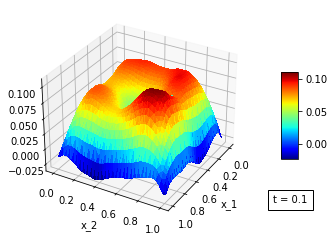

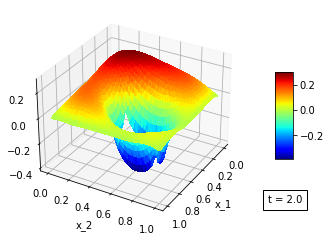

In [21]:
plot_sampler = tp.samplers.PlotSampler(plot_domain=omega, n_points=2000, data_for_other_variables={"t": 0.1})
fig = tp.utils.plot(model, lambda u : u, plot_sampler)


plot_sampler = tp.samplers.PlotSampler(plot_domain=omega, n_points=2000, data_for_other_variables={"t": 2.0})
fig = tp.utils.plot(model, lambda u : u, plot_sampler)

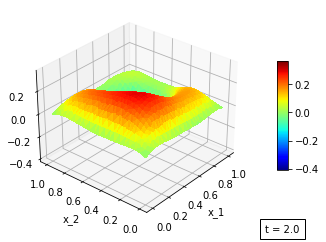

In [ ]:
# We can also animate the solution over time
anim_sampler = tp.samplers.AnimationSampler(omega, time_interval, 200, n_points=1000)
fig, anim = tp.utils.animate(model, lambda u: u, anim_sampler, ani_speed=10, angle=[30, 220])
anim.save('heat-eq-cooler.gif')
# You should be able to see a tab with a folder on the left side of your screen. There you can find the gif and can watch it.